# Reliability Event Detector: analysis sandbox

Identify daily station impairment, investigate shared patterns, and estimate
energy shortfalls in a synthetic DC charging network.

The three input tables describe 18 sites, 108 connectors, and 84 days of charging
attempts. The detector uses attempt logs and station metadata. Injected scenario
labels remain in the data generator and are not inputs to detection.

The [README](README.md) documents the data model, exact rules, baselines,
statistical assumptions, output definitions, and limitations.

## Approach

1. Include every station-day, including days without recorded attempts.
2. Estimate same-weekday activity baselines and network success-rate baselines.
3. Flag authorization, start, activity, and power-delivery impairment.
4. Compare groups by site, reader, firmware, and site type with the rest of the network.
5. Summarize the strongest group association per day and estimate energy shortfall.

Baselines use the full observation window, making this a retrospective analysis.
Group labels describe associations rather than confirmed root causes.

Reusable code lives in [reliability_detector/](reliability_detector/). This notebook
loads it, keeps intermediate tables available for exploration, and walks through
the examples. Open the notebook from the project folder and run cells in order.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from reliability_detector.data import load_data, build_station_days
from reliability_detector.detection import flag_station_impairment, detect_systemic_events
from reliability_detector import plots, summaries

sns.set_theme(style="whitegrid", context="talk", font_scale=0.85)

DATA_DIR = Path("data")
SITES_CSV = DATA_DIR / "sites.csv"
STATIONS_CSV = DATA_DIR / "stations.csv"
ATTEMPTS_CSV = DATA_DIR / "attempts.csv"


## Detect reliability events

The [data module](reliability_detector/data.py) loads the CSVs and builds a complete
station-day table. The [detection module](reliability_detector/detection.py) adds the
impairment flags and tests shared groups. Keeping these steps visible makes it easy
to inspect `station_day_df` or reuse it with different cohort settings.

- Authorization and conditional-start impairment use lower-tail binomial tests.
- Low activity uses a lower-tail Poisson test against the station's same-weekday median.
- Power impairment requires at least four sessions with median power below 25 kW,
  or at least two zero-energy sessions.

Statistical impairment tests use a 1% per-test cutoff. Those station-level tests
are unadjusted. Candidate-group comparisons use a separate daily Bonferroni
adjustment. These choices do not guarantee a 1% pipeline-wide false-positive rate.
Authorization failures are excluded from the start-rate denominator.


In [2]:
sites_df, stations_df, attempts_df = load_data(
    SITES_CSV, STATIONS_CSV, ATTEMPTS_CSV,
)
station_day_df = build_station_days(sites_df, stations_df, attempts_df)
station_day_df = flag_station_impairment(station_day_df)


## Run the analysis


In [3]:
daily_df = detect_systemic_events(station_day_df)

print(
    f"Days with selected group-level events: "
    f"{daily_df['has_systemic_failure'].sum()} / "
    f"{len(daily_df)}"
)
print(daily_df.loc[daily_df["has_systemic_failure"], [
    "date", "num_stations_impaired", "num_stations_systemic",
    "event_type", "correlates",
]].to_string(index=False))


Days with selected group-level events: 24 / 84
      date  num_stations_impaired  num_stations_systemic           event_type                        correlates
2025-04-20                     29                     28    reader-associated             reader_type: reader_b
2025-04-21                     27                     26    reader-associated             reader_type: reader_b
2025-04-22                     31                     28    reader-associated             reader_type: reader_b
2025-04-23                     27                     27    reader-associated             reader_type: reader_b
2025-04-24                     30                     28    reader-associated             reader_type: reader_b
2025-04-25                     30                     28    reader-associated             reader_type: reader_b
2025-04-26                     31                     28    reader-associated             reader_type: reader_b
2025-04-27                     28                     28 

### Output validation


In [4]:
assert daily_df["date"].is_unique
assert len(daily_df) == station_day_df["date"].nunique()
assert daily_df["num_stations_systemic"].le(daily_df["num_stations_impaired"]).all()
print("One row per date; selected systemic stations are a subset of impaired stations.")


One row per date; selected systemic stations are a subset of impaired stations.


### Detected systemic-event summary


In [5]:
event_summary_df = summaries.summarize_events(daily_df)
print(event_summary_df.round(2).to_string(index=False))


          event_type                        correlates  systemic_days  peak_stations_systemic  mean_auth_rate_pct  mean_start_rate_pct  mean_demand_pct
   reader-associated             reader_type: reader_b              9                      28               32.59                95.62           171.30
 firmware-associated firmware_version: v4.2.0 + v4.3.0              5                      61               96.87                28.47           171.38
site-type-associated      site_type: Highway Rest Stop              5                      14               96.36                95.74            58.66
     site-associated                  site_id: HUB_206              3                       4                 NaN                  NaN             0.00
     site-associated                  site_id: HUB_213              2                       6              100.00                96.66             7.05


## Prepare the visualization data

The daily output summarizes selected group associations. The [summary functions](reliability_detector/summaries.py) reuse the prepared
station-day metrics to build network, firmware, and energy-impact tables.

Expected daily attempts and kWh use each station's full-window same-weekday
median. Energy shortfall is a reference-based estimate, not a causal loss estimate.


In [6]:
network_daily_metrics_df = summaries.network_metrics(station_day_df, daily_df)


## Network reliability over time

Gray bars show all impaired stations. Colored overlays show the subset
attributed to the selected systemic event, so systemic stations are not
double-counted.


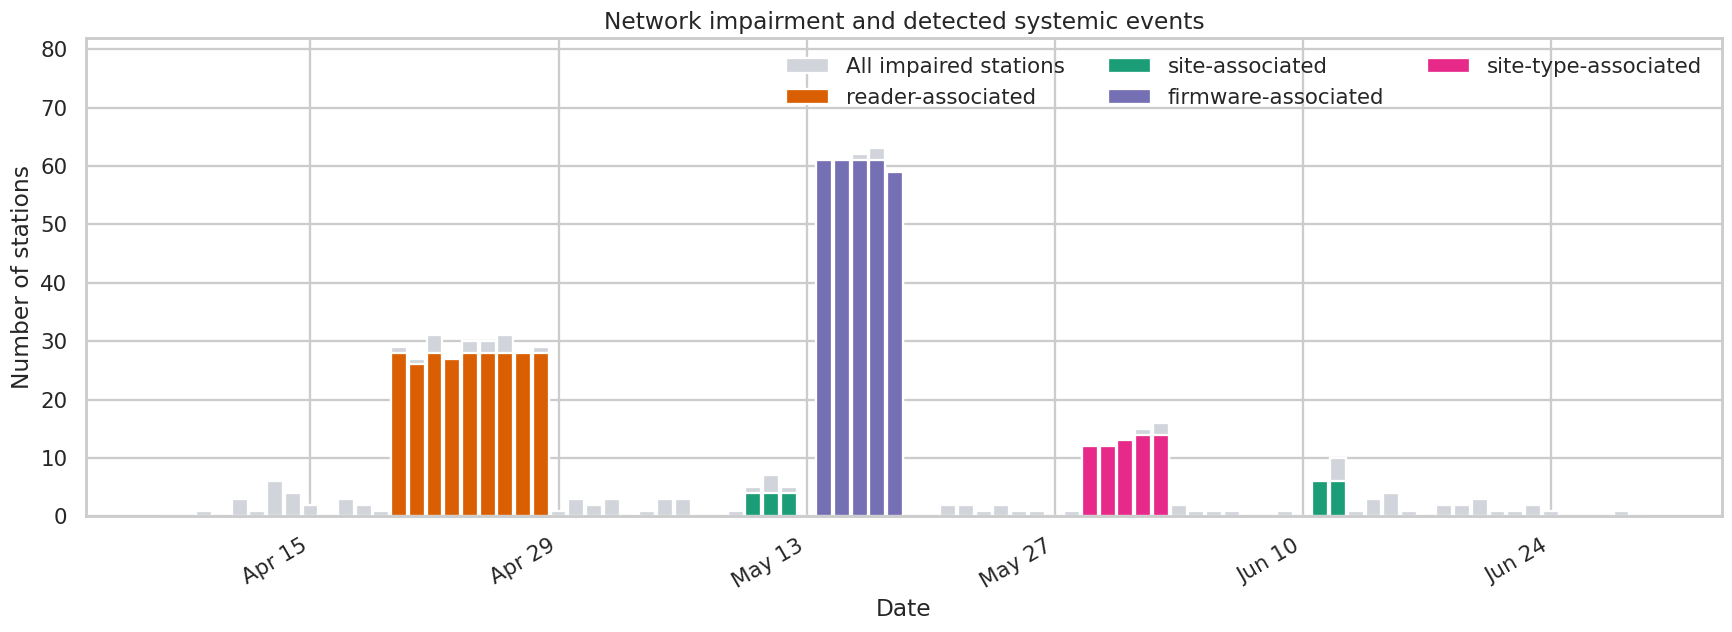

In [7]:
fig, ax = plots.plot_network_reliability(daily_df)
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/network_reliability.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)


## Systemic station days

The heatmap shows impaired stations within the selected group on each date.
Stations are ordered by reader type, site, and station ID to separate cross-site
patterns from local concentrations. The colors identify associated group types.


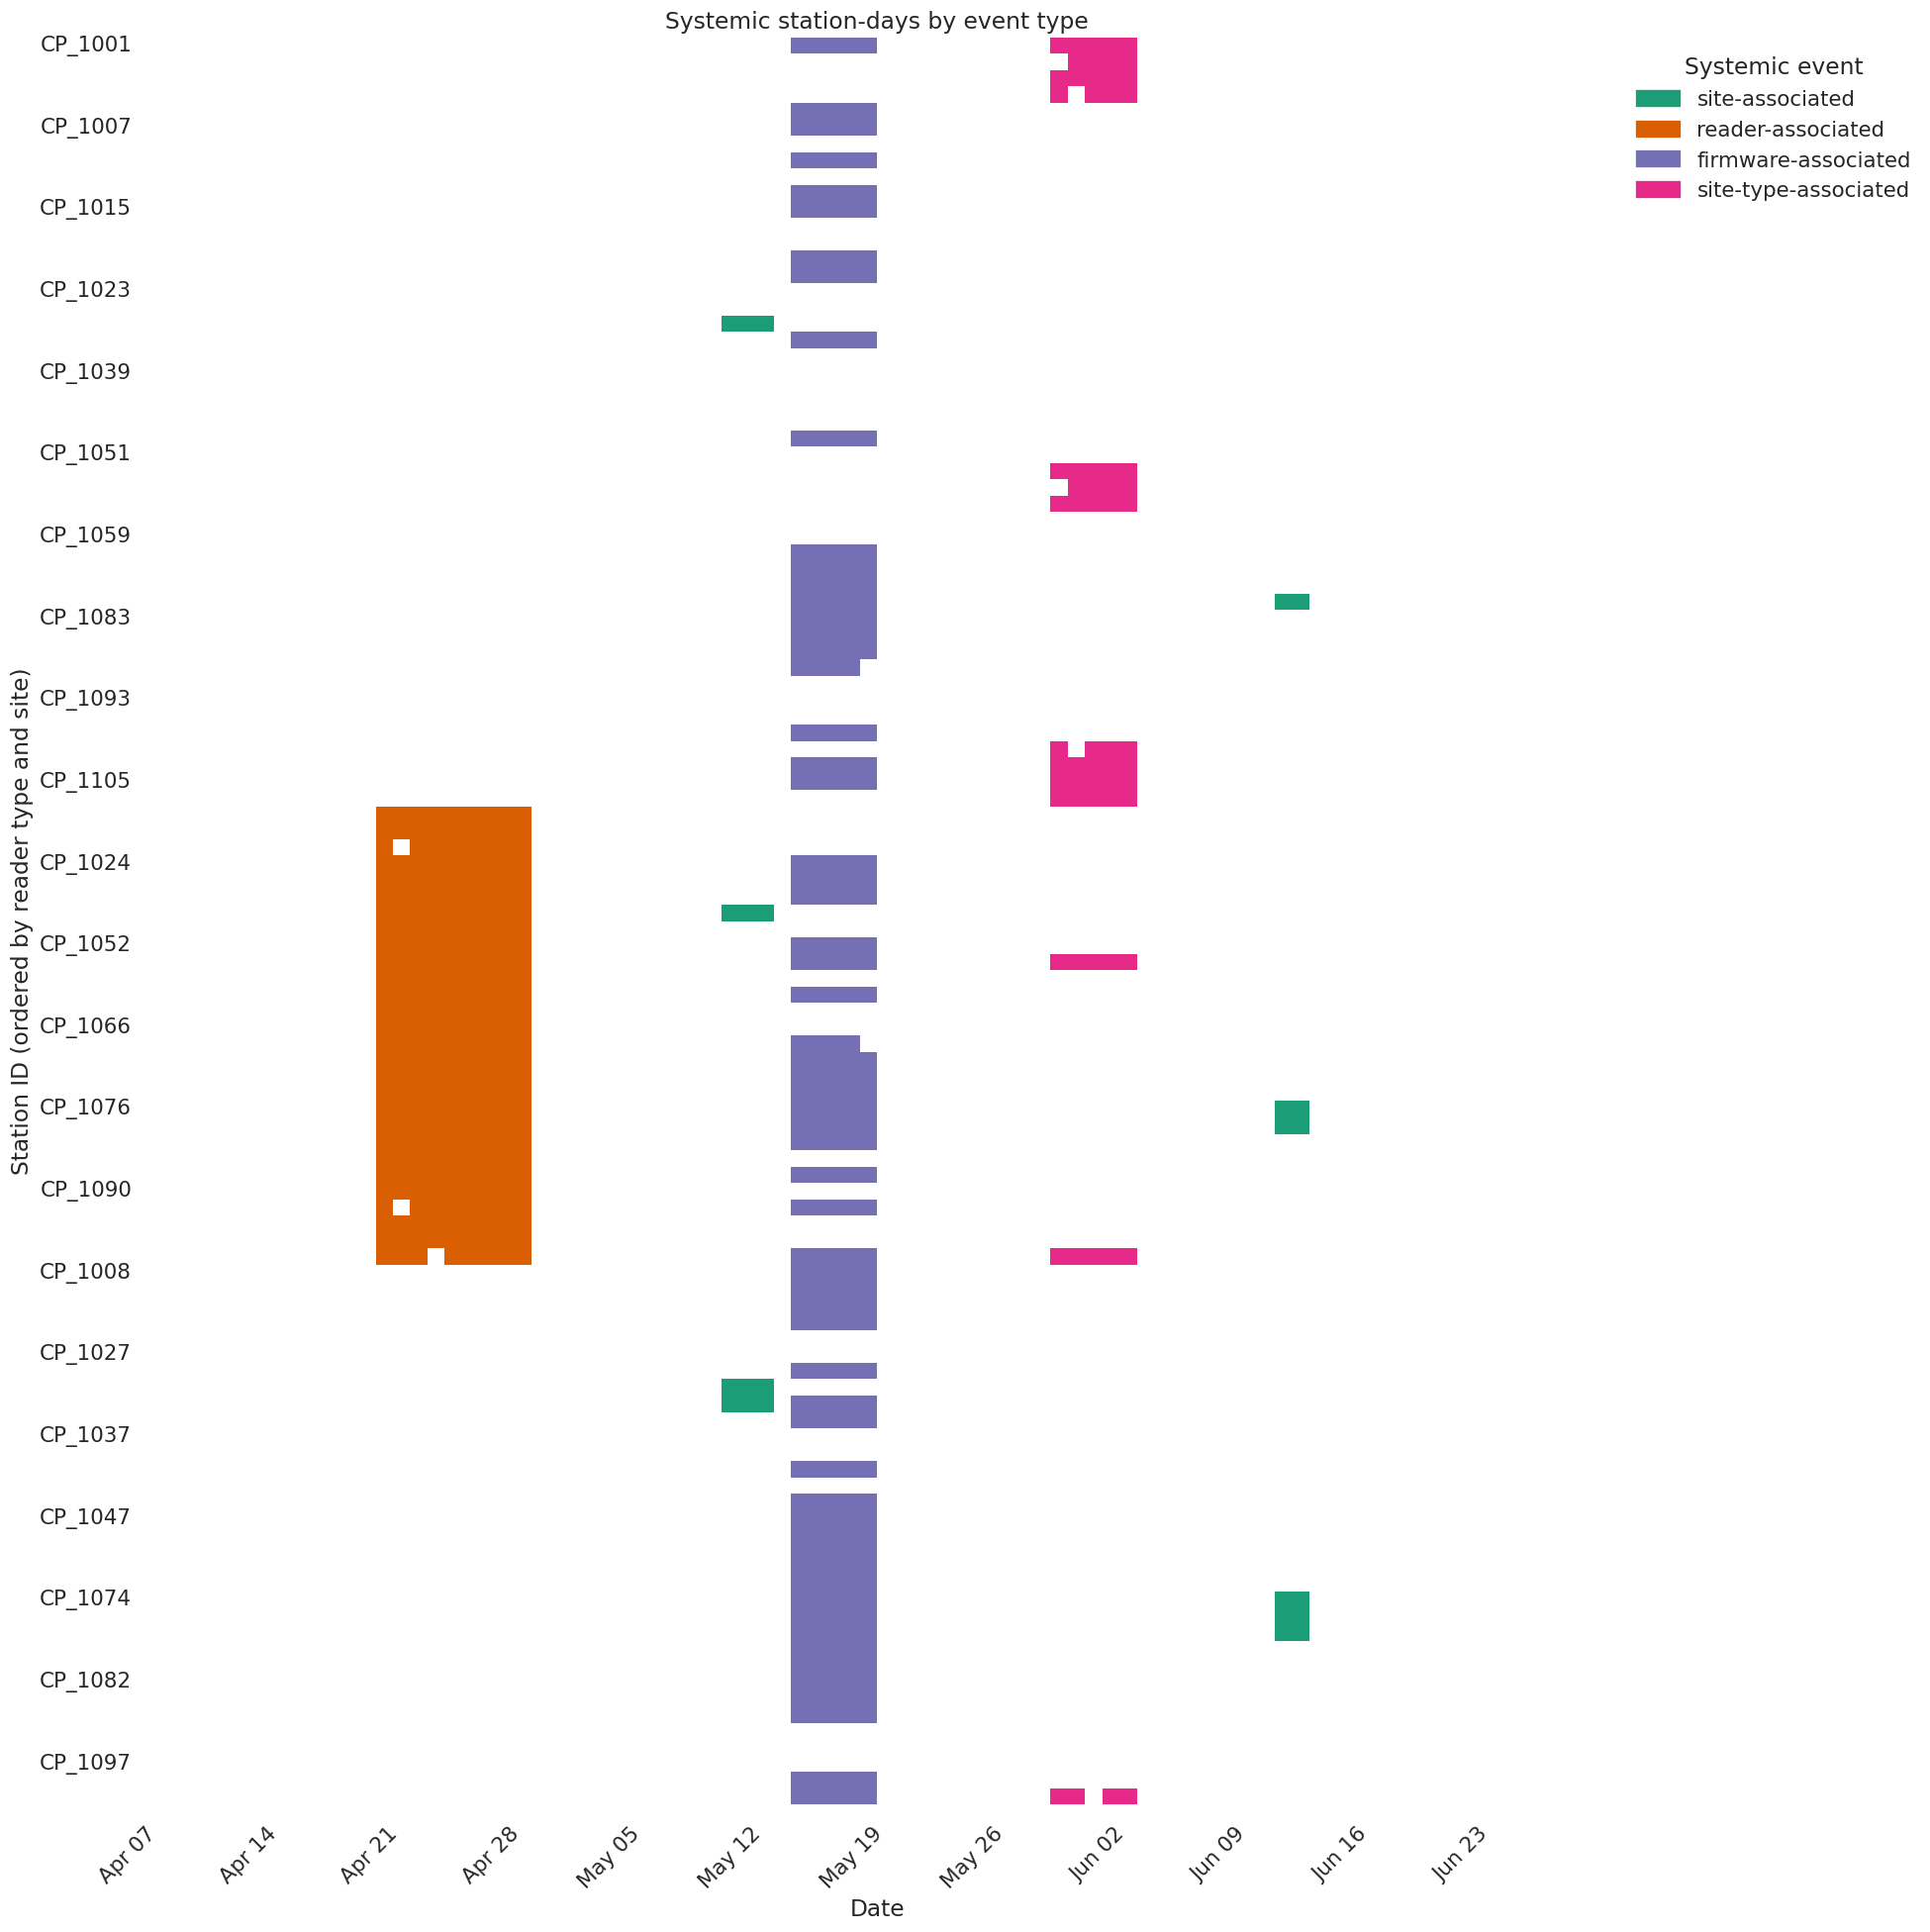

In [8]:
fig, ax = plots.plot_systemic_stations(daily_df, stations_df)
plt.show()
plt.close(fig)


## What firmware aggregates hide

A whole-period average cannot show when performance deteriorated or how severe
a short event became. Daily conditional start rates separate the affected
firmware versions from the comparatively stable version.

The shaded interval is the firmware event selected by the detector. The table
below compares whole-period, outside-event, and during-event rates. Each rate
pools sessions and observable starts within the stated version and period.


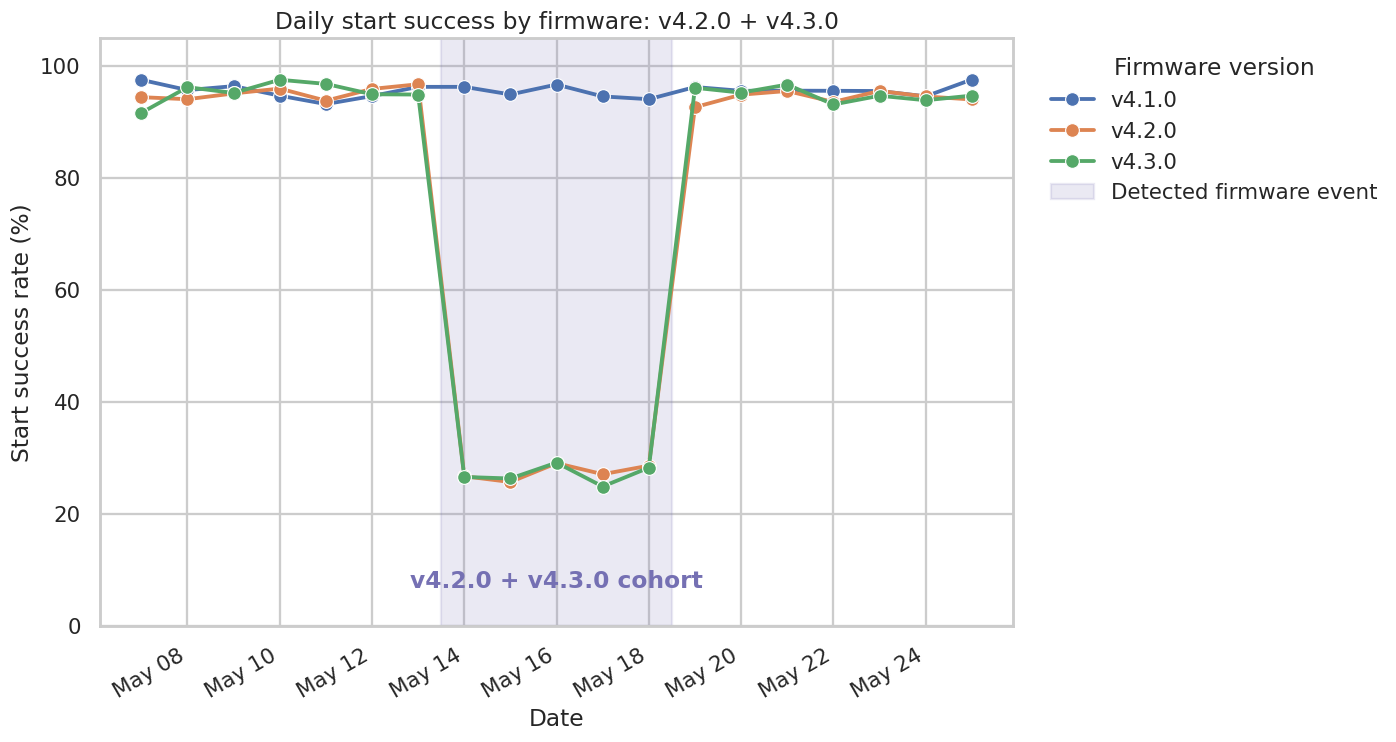

firmware_version  v4.1.0  v4.2.0  v4.3.0
date                                    
2025-05-14          96.3    26.8    26.6
2025-05-15          94.9    25.8    26.4
2025-05-16          96.7    29.1    29.2
2025-05-17          94.6    27.1    24.9
2025-05-18          94.1    28.7    28.3


In [9]:
firmware_start_daily_df = summaries.firmware_start_rates(attempts_df, stations_df)

# This example contains one contiguous firmware event. For other data, choose
# one event interval rather than combining separated incidents.
firmware_event_df = daily_df.loc[daily_df["event_type"].eq("firmware-associated")]
firmware_event_dates = pd.to_datetime(firmware_event_df["date"])
firmware_event_start = firmware_event_dates.min()
firmware_event_end = firmware_event_dates.max()
firmware_correlate = firmware_event_df["correlates"].iloc[0].replace("firmware_version: ", "")

fig, ax = plots.plot_firmware_start_rates(
    firmware_start_daily_df, firmware_event_start, firmware_event_end, firmware_correlate,
)
plt.show()
plt.close(fig)

firmware_event_rates_df = firmware_start_daily_df.loc[
    firmware_start_daily_df["date"].between(firmware_event_start, firmware_event_end)
].pivot(index="date", columns="firmware_version", values="start_rate_pct")
print(firmware_event_rates_df.round(1).to_string())


In [10]:
firmware_period_summary_df = summaries.firmware_period_rates(
    firmware_start_daily_df, firmware_event_start, firmware_event_end,
)
print(firmware_period_summary_df.round(1).to_string())


                  Whole period  Outside event  During event
firmware_version                                           
v4.1.0                    95.5           95.5          95.2
v4.2.0                    87.9           94.7          27.5
v4.3.0                    88.4           95.1          27.0


### Why evaluate versions together?

When two versions share a start problem, testing one version against the rest
places the other affected version in its comparison population. This reduces
the separation between the group and its comparator. Combining both versions
compares their shared pattern with the remaining firmware version.

Here the single-version-only detector still flags all five event days. With one
selected group per day, it reports only one affected version. The cohort run
captures the broader affected population. The comparison below uses identical
station impairment rules. Each run adjusts the group-test threshold for its own
candidate count, 30 without cohorts and 33 with cohorts.


In [11]:
single_version_daily_df = detect_systemic_events(
    station_day_df,
    include_firmware_cohorts=False,
)
firmware_comparison_df = daily_df.loc[
    daily_df["date"].between(str(firmware_event_start.date()), str(firmware_event_end.date())),
    ["date", "num_stations_systemic"],
].rename(columns={"num_stations_systemic": "With cohorts"}).merge(
    single_version_daily_df[["date", "num_stations_systemic"]].rename(
        columns={"num_stations_systemic": "Single versions only"}
    ), on="date", validate="one_to_one",
)
print(firmware_comparison_df.to_string(index=False))


      date  With cohorts  Single versions only
2025-05-14            61                    37
2025-05-15            61                    37
2025-05-16            61                    37
2025-05-17            61                    37
2025-05-18            59                    36


## Attempt volume compared with delivered energy

An increase in logged attempts can coincide with lower delivered energy.
Retries contribute to attempt volume, so attempts are not unique customers.
The chart uses network totals divided by summed station baselines.


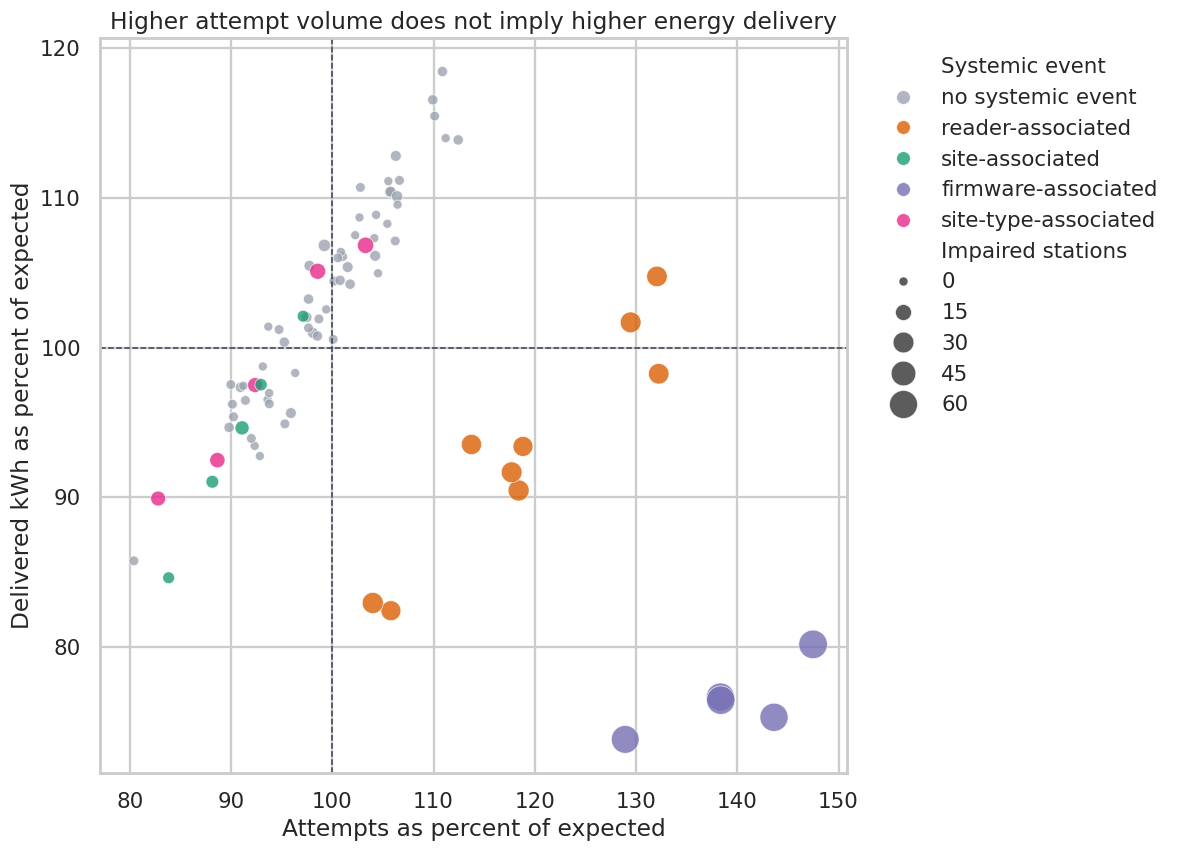

In [12]:
fig, ax = plots.plot_demand_vs_energy(network_daily_metrics_df)
plt.show()
plt.close(fig)


In [13]:
demand_energy_summary_df = summaries.demand_energy_summary(network_daily_metrics_df)
print(demand_energy_summary_df.round(1).to_string(index=False))


systemic_status  mean_demand_pct  median_demand_pct  mean_delivered_kwh_pct  median_delivered_kwh_pct
   Non-systemic             99.5               99.7                   103.6                     104.3
       Systemic            112.0              109.8                    91.0                      92.1


## Attempt outcomes over time

The raw attempt outcomes provide a direct view of how failure episodes
differ. The markers above the chart indicate dates with a detected
systemic event.


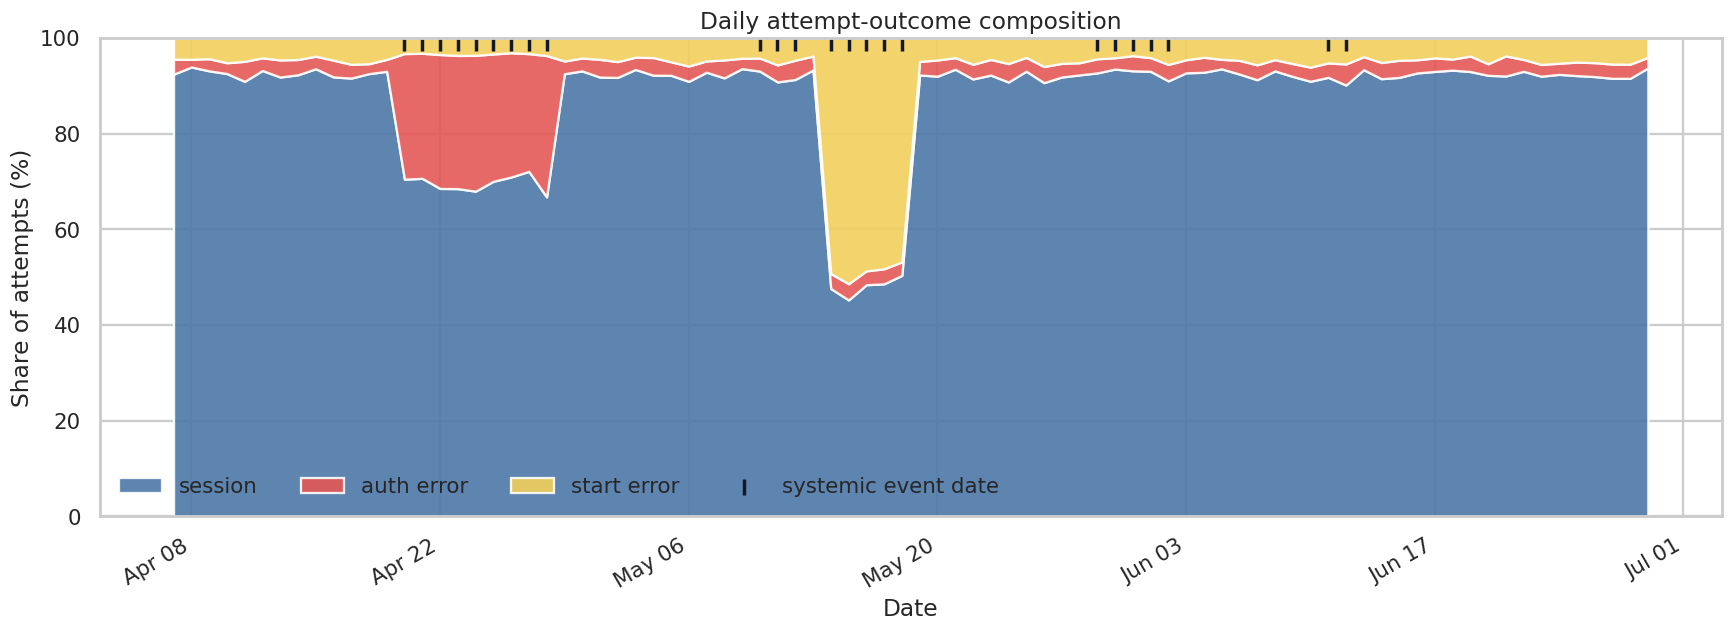

In [14]:
daily_outcome_pct_df = summaries.daily_outcome_percentages(attempts_df)
fig, ax = plots.plot_attempt_outcomes(daily_outcome_pct_df, daily_df)
plt.show()
plt.close(fig)


## Estimated kWh shortfall

For each selected station, expected kWh is its same-weekday median. Expected
and actual energy are summed across selected stations on a date, then the
difference is clipped at zero. Consecutive dates with the same event type and
correlate form episodes. This is an operational estimate, not causal lost energy.


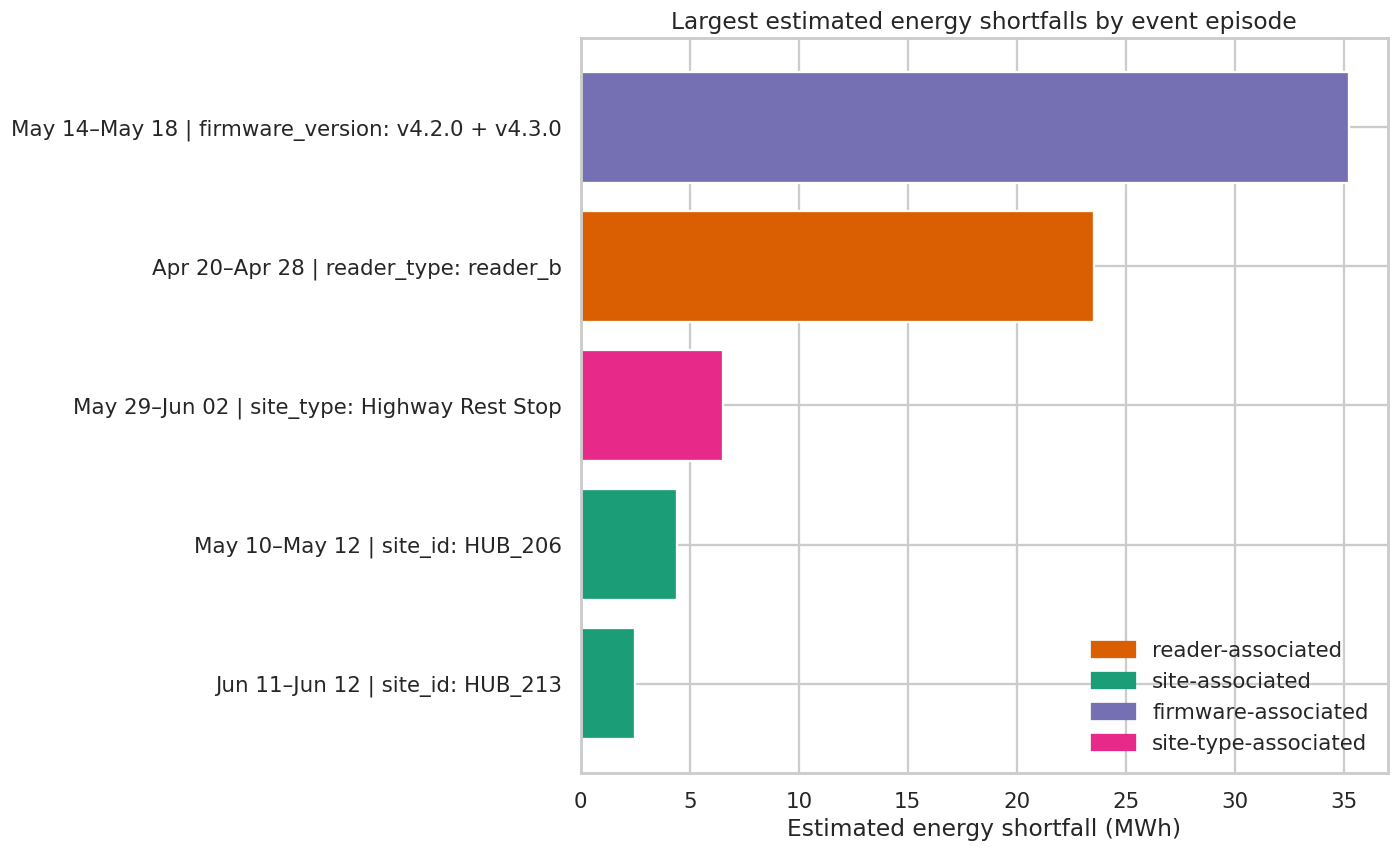

In [15]:
event_day_impact_df = summaries.estimate_energy_shortfall(station_day_df, daily_df)
episode_metrics_df = summaries.summarize_episodes(event_day_impact_df)
fig, ax = plots.plot_episode_shortfalls(episode_metrics_df)
plt.show()
plt.close(fig)


## Estimated kWh shortfall by correlate

The Pareto chart ranks associations by estimated shortfall among selected
impaired stations. It helps prioritize investigation. It excludes isolated
impairments and groups not selected in the daily summary.


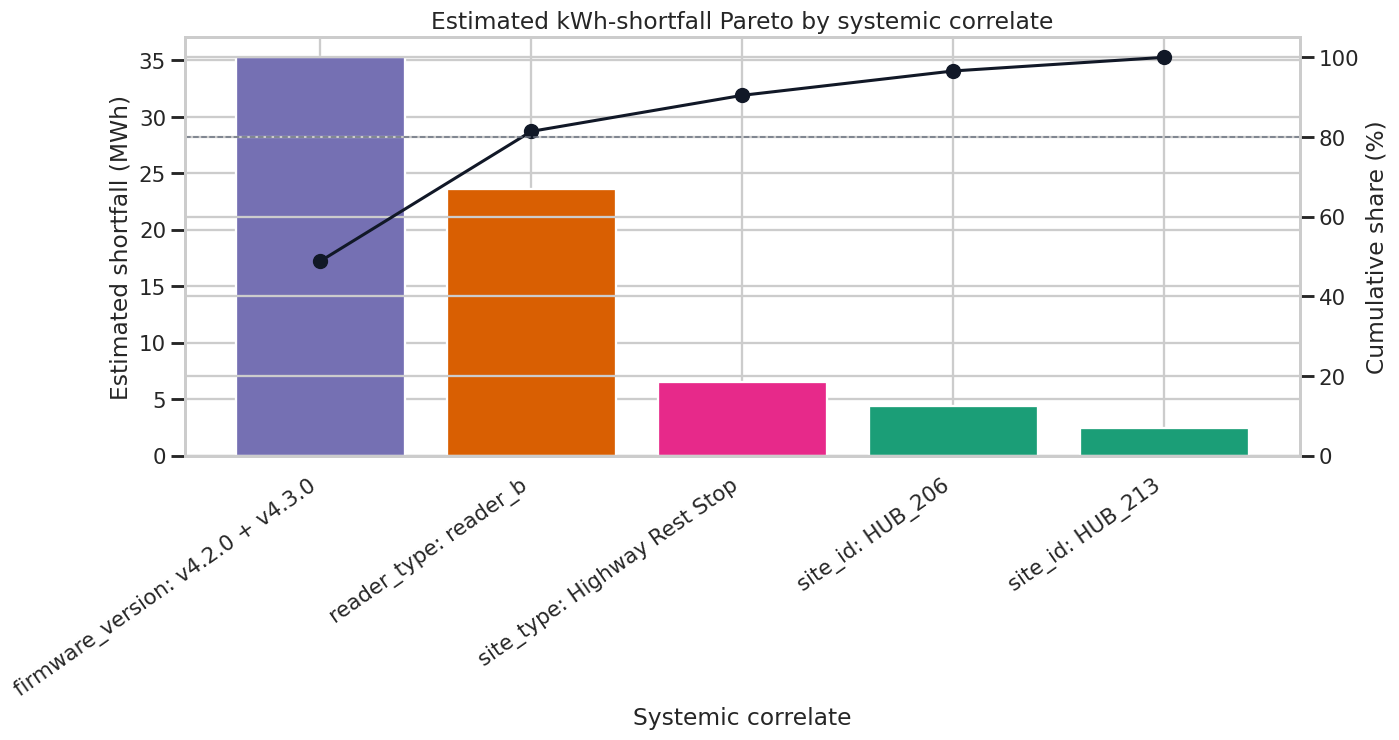

          event_type                        correlates  shortfall_mwh  cumulative_pct
 firmware-associated firmware_version: v4.2.0 + v4.3.0          35.27           48.79
   reader-associated             reader_type: reader_b          23.56           81.40
site-type-associated      site_type: Highway Rest Stop           6.55           90.45
     site-associated                  site_id: HUB_206           4.42           96.57
     site-associated                  site_id: HUB_213           2.48          100.00


In [16]:
correlate_impact_df = summaries.summarize_correlates(event_day_impact_df)
fig, ax = plots.plot_correlate_shortfalls(correlate_impact_df)
plt.show()
plt.close(fig)

print(correlate_impact_df[
    ["event_type", "correlates", "shortfall_mwh", "cumulative_pct"]
].round(2).to_string(index=False))


## Key takeaways


In [17]:
systemic_days = int(daily_df["has_systemic_failure"].sum())
total_shortfall_mwh = (
    event_day_impact_df["estimated_kwh_shortfall"].sum()
    / 1000
)
leading_correlate = correlate_impact_df.iloc[0]
leading_share = leading_correlate["cumulative_pct"]

print(f"Detected systemic events on {systemic_days} of {len(daily_df)} days.")
print(
    "Estimated systemic-event energy shortfall: "
    f"{total_shortfall_mwh:,.1f} MWh."
)
print(
    "Highest-priority correlate: "
    f"{leading_correlate['correlates']} "
    f"({leading_share:.1f}% of estimated shortfall)."
)


Detected systemic events on 24 of 84 days.
Estimated systemic-event energy shortfall: 72.3 MWh.
Highest-priority correlate: firmware_version: v4.2.0 + v4.3.0 (48.8% of estimated shortfall).


## Interpretation and limitations

- Daily rates expose event timing and severity hidden by whole-period averages.
- Combined firmware cohorts can reveal a broader affected population than a
  one-version-versus-rest comparison. In this dataset both approaches flag the
  five-day event, but the cohort approach selects more affected stations.
- Retries make attempt counts larger than the number of visiting customers and
  weaken the independence assumptions behind the binomial tests.
- Missing activity can indicate low use, an outage, communications loss, or missing logs.
- Baselines include the evaluated day and future observations. Prolonged faults
  can contaminate those baselines.
- A daily summary selects one group, so simultaneous or network-wide issues may
  not be fully represented.
- Energy shortfall is a prioritization estimate, not measured causal loss.
- Agreement with injected scenarios on one seed does not establish accuracy on
  other seeds or real networks. See the README for the complete assumptions.
